In [1]:
%run -i ../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
from scipy.optimize import minimize
import seaborn as sns
import plotly.express as px

In [3]:
def diff(p):
    b, n1, r1, n2, r2 = p
    n1 = int(round(n1))
    n2 = int(round(n2))
    e1 = int(n1 * r1)
    e2 = int(n2 * r2)
    return binom_sum(b=b, e=e1, n=n1) - binom_sum(b=b, e=e2, n=n2)

In [4]:
def safe_diff(p):  # if optimization fails
    try:
        val = diff(p)
        if not np.isfinite(val):
            return 1e20
        return val
    except Exception:
        return 1e20

In [7]:
N_RUNS = 1000
TOL = 1e-8  # tolerance for "minimum = 0"

bounds = [(0, 1), (1, 100000), (0, 1), (1, 100000), (0, 1)]
constraints = [
    {"type": "ineq", "fun": lambda p: p[1] - p[3] - 1},  # n1 > n2
    {"type": "ineq", "fun": lambda p: p[2] - p[4]},  # r1 > r2
]

solutions = []
for _ in tqdm(range(N_RUNS)):
    x0 = [
        (
            rd.randint(lo, hi)
            if isinstance(lo, int) and isinstance(hi, int)
            else rd.uniform(lo, hi)
        )
        for lo, hi in bounds
    ]

    result = minimize(
        safe_diff, x0, bounds=bounds, constraints=constraints, method="SLSQP"
    )

    if result.success and abs(result.fun) < TOL:
        solutions.append(result.x)

solutions = np.array(solutions)

100%|██████████| 1000/1000 [11:06<00:00,  1.50it/s] 


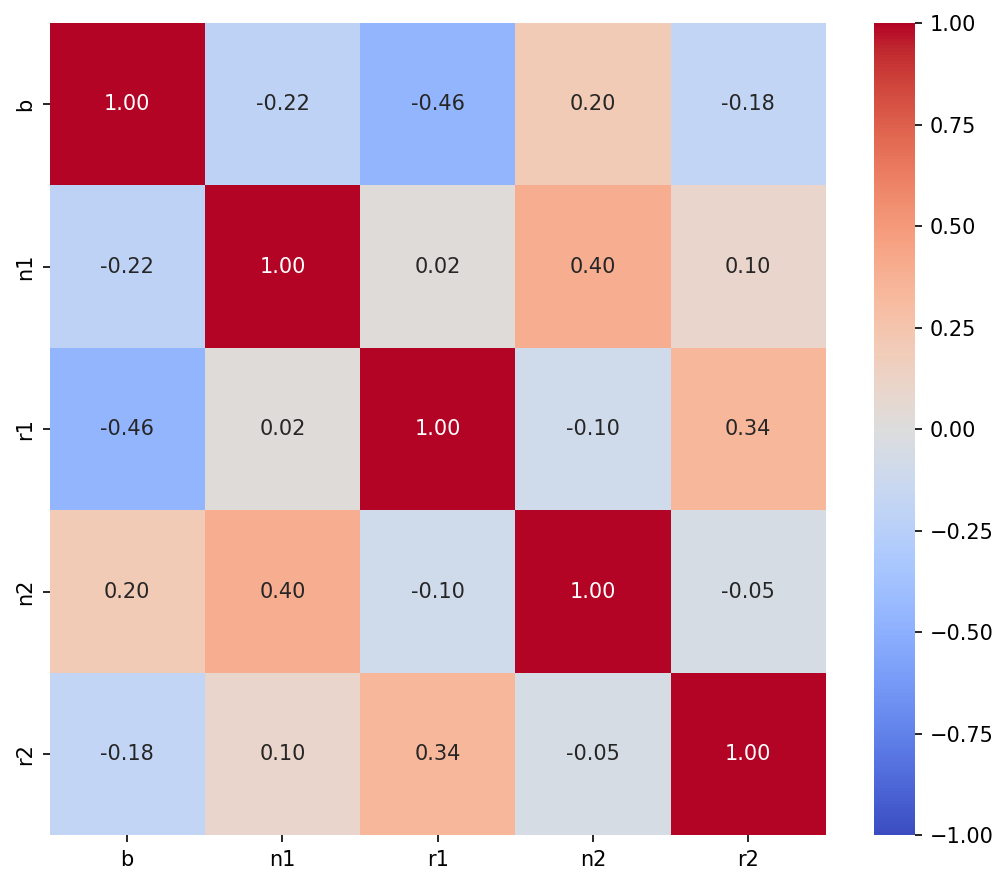

In [8]:
corr = np.corrcoef(solutions, rowvar=False)
param_names = ["b", "n1", "r1", "n2", "r2"]

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    xticklabels=param_names,
    yticklabels=param_names,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.tight_layout()
plt.show()

In [ ]:
df = pd.DataFrame(solutions, columns=param_names)
# drop constant columns
df = df.loc[:, df.nunique() > 1]

fig = px.scatter_matrix(df, dimensions=df.columns, opacity=0.3)
fig.show()

##### Random exploration 

In [16]:
bs, diffs = [], []

for _ in tqdm(range(500)):
    b = rd.uniform(0, 0.99)
    n1 = rd.randint(2, 100000)
    n2 = rd.randint(1, n1 - 1)
    r1 = rd.uniform(0, 1)
    r2 = rd.uniform(0, r1)

    e1 = int(n1 * r1)
    e2 = int(n2 * r2)
    diff = binom_sum(b=b, e=e1, n=n1) - binom_sum(b=b, e=e2, n=n2)

    bs.append(b)
    diffs.append(diff)

100%|██████████| 500/500 [01:07<00:00,  7.43it/s]


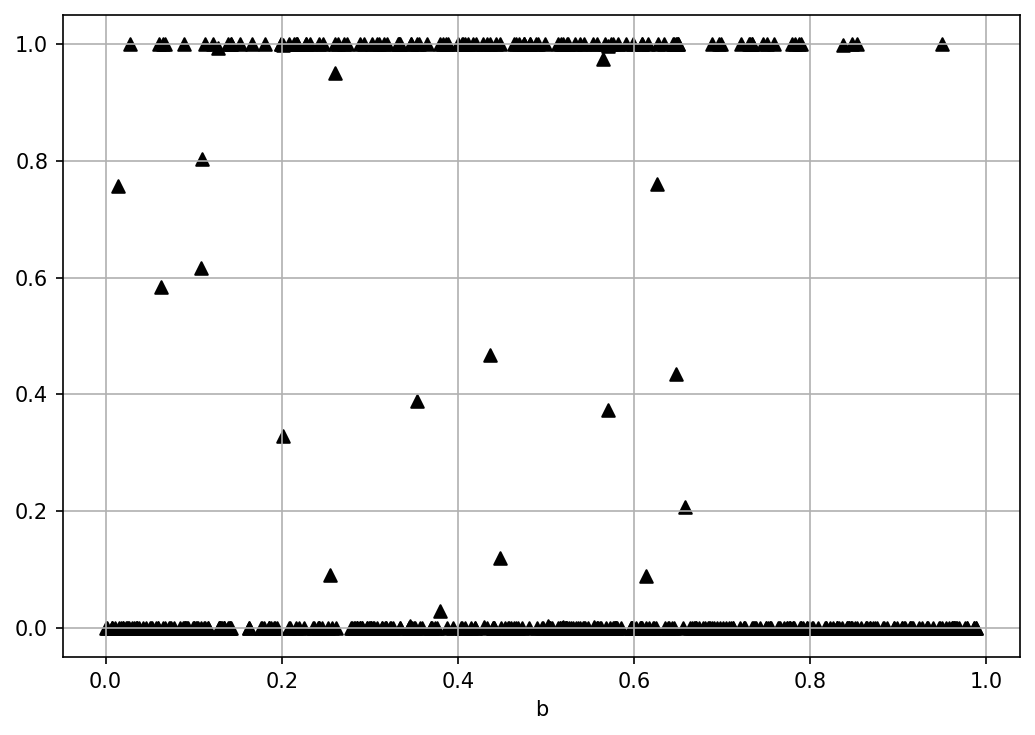

In [17]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(bs, diffs, marker="^", c="black")  # , c=v, cmap="coolwarm", alpha=0.7)
# plt.colorbar(sc, label=r"$n_1 - n_2$")
plt.xlabel("b")
plt.tight_layout()
plt.grid()
plt.show()